<a href="https://colab.research.google.com/github/maikol0629/dl_voice_command_cl/blob/main/06%20-%20evaluaci%C3%B3n%20de%20robustez.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluación de Robustez: Comparación de Modelos frente a Ataques Adversariales

Este notebook carga los tres modelos entrenados (CNN Baseline, CRNN y SpectroTransformer) y los evalúa tanto en el conjunto de validación limpio como en el conjunto de test adversarial. Se comparan las métricas de accuracy y se analiza la caída de rendimiento frente a perturbaciones adversarias.

In [8]:
# Colab setup
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    import os
    try:
        from google.colab import userdata
        os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')
        os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')
    except Exception:
        pass

    !pip install -q kagglehub torch torchaudio pandas numpy matplotlib scikit-learn librosa soundfile audioread numba
    import kagglehub
    import shutil

    try:
        data_path = kagglehub.competition_download("voice-commands-classification-2026")
    except Exception as e:
        print("Error al descargar de Kaggle. Asegúrate de configurar KAGGLE_USERNAME y KAGGLE_KEY en tus Colab Secrets.")
        raise e

    if not os.path.exists('data'):
        os.symlink(data_path, 'data')

    if not os.path.exists('dl_voice_command_cl'):
        !git clone https://github.com/maikol0629/dl_voice_command_cl.git

    for f in ['train_metadata.csv', 'test_metadata.csv', 'best_cnn_baseline.pth']:
        src = os.path.join('dl_voice_command_cl', f)
        if os.path.exists(src) and not os.path.exists(f):
            shutil.copy(src, '.')
    for f in ['models.py', 'data.py']:
        src = os.path.join('dl_voice_command_cl', f)
        if os.path.exists(src) and not os.path.exists(f):
            shutil.copy(src, '.')

import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio.transforms as T

from models import AudioToMelSpectrogram, BaselineCNN, CRNNModel, SpectrogramTransformer
from data import load_data, load_adv_test
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando dispositivo: {device}")

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)


Usando dispositivo: cuda


In [9]:
SAMPLE_RATE = 16000
N_CLASSES = 35
BATCH_SIZE = 64
N_MELS = 64
N_FFT = 1024
HOP_LENGTH = 256
MAX_SAMPLES = SAMPLE_RATE
SEED = 42

if not IN_COLAB and not os.path.exists('data'):
    print("Descargando dataset de Kaggle (esto toma ~3GB)...")
    !pip install -q kagglehub
    import kagglehub
    data_path = kagglehub.competition_download("voice-commands-classification-2026")
    os.symlink(data_path, 'data')

DATA_PATH = Path('./data')
TRAIN_AUDIO_DIR = DATA_PATH / 'train/train/train'
ADV_TEST_DIR = DATA_PATH / 'adv_test'

np.random.seed(SEED)
torch.manual_seed(SEED)

In [10]:
_, val_loader, label_encoder, num_classes = load_data(
    train_metadata_csv='train_metadata.csv',
    train_audio_dir=str(TRAIN_AUDIO_DIR),
    val_size=0.2, seed=SEED, batch_size=BATCH_SIZE,
)
classes = label_encoder.classes_
print(f"Clases: {len(classes)}")
print(f"Val muestras: {len(val_loader.dataset)}")

adv_loader, adv_count = load_adv_test(
    test_dir=str(ADV_TEST_DIR), label_encoder=label_encoder, batch_size=BATCH_SIZE
)
if adv_loader is not None:
    print(f"Adv test muestras: {adv_count}")
else:
    print("No se encontro metadata.csv para adv_test o no contiene columna 'label'")
    adv_loader = None

Clases: 35
Val muestras: 19050
No se encontro metadata.csv para adv_test o no contiene columna 'label'


In [11]:
# Crear transformación a Mel-spectrogram
audio_transform = AudioToMelSpectrogram(
    sample_rate=SAMPLE_RATE, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS
).to(device)


In [12]:
def create_dummy_model(model_class, num_classes, **kwargs):
    model = model_class(num_classes, **kwargs)
    for p in model.parameters():
        nn.init.normal_(p, mean=0.0, std=0.02)
    return model

models_info = []

try:
    cnn = BaselineCNN(N_CLASSES).to(device)
    cnn.load_state_dict(torch.load('best_cnn_baseline.pth', map_location=device))
    cnn.eval()
    models_info.append(('CNN Baseline', cnn))
    print("CNN Baseline: pesos cargados")
except Exception as e:
    print(f"CNN Baseline: no se pudo cargar ({e}), creando dummy")
    cnn = create_dummy_model(BaselineCNN, N_CLASSES).to(device)
    cnn.eval()
    models_info.append(('CNN Baseline', cnn))

try:
    crnn = CRNNModel(N_CLASSES, lstm_hidden=128).to(device)
    crnn.load_state_dict(torch.load('best_crnn.pth', map_location=device))
    crnn.eval()
    models_info.append(('CRNN', crnn))
    print("CRNN: pesos cargados")
except Exception as e:
    print(f"CRNN: no se pudo cargar ({e}), creando dummy")
    crnn = create_dummy_model(CRNNModel, N_CLASSES, lstm_hidden=128).to(device)
    crnn.eval()
    models_info.append(('CRNN', crnn))

try:
    trans = SpectrogramTransformer(N_CLASSES, dim=120, depth=4, heads=6).to(device)
    trans.load_state_dict(torch.load('best_transformer.pth', map_location=device))
    trans.eval()
    models_info.append(('Transformer', trans))
    print("Transformer: pesos cargados")
except Exception as e:
    print(f"Transformer: no se pudo cargar ({e}), creando dummy")
    trans = create_dummy_model(SpectrogramTransformer, N_CLASSES, dim=120, depth=4, heads=6).to(device)
    trans.eval()
    models_info.append(('Transformer', trans))

CNN Baseline: pesos cargados
CRNN: pesos cargados
Transformer: pesos cargados


In [13]:
@torch.inference_mode()
def evaluate_model(model, loader, device, model_name):
    model.eval()
    y_true = []
    y_pred = []
    for audios, labels in loader:
        audios = audios.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        mels = audio_transform(audios)
        outputs = model(mels)
        preds = outputs.argmax(dim=1)
        y_true.extend(labels.cpu().tolist())
        y_pred.extend(preds.cpu().tolist())
    accuracy = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(
        y_true, y_pred, target_names=classes, zero_division=0, digits=4
    )
    return accuracy, cm, report

In [14]:
print("=" * 60)
print("EVALUACION EN VALIDACION LIMPIA")
print("=" * 60)

val_results = {}
for name, model in models_info:
    acc, cm, report = evaluate_model(model, val_loader, device, name)
    val_results[name] = {'accuracy': acc, 'confusion_matrix': cm, 'report': report}
    print(f"\n--- {name} ---")
    print(f"Accuracy: {acc * 100:.2f}%")
    print(report)

print("\n" + "=" * 60)

EVALUACION EN VALIDACION LIMPIA

--- CNN Baseline ---
Accuracy: 88.94%
              precision    recall  f1-score   support

    backward     0.9729    0.8480    0.9061       296
         bed     0.7313    0.8623    0.7914       363
        bird     0.9393    0.7882    0.8571       373
         cat     0.9104    0.8654    0.8873       364
         dog     0.9388    0.8016    0.8648       383
        down     0.8414    0.9217    0.8797       702
       eight     0.9467    0.9356    0.9411       683
        five     0.8962    0.9330    0.9142       731
      follow     0.7631    0.7711    0.7671       284
     forward     0.8950    0.6439    0.7490       278
        four     0.8886    0.8754    0.8819       674
          go     0.8699    0.8214    0.8450       700
       happy     0.9183    0.9158    0.9170       368
       house     0.9330    0.9134    0.9231       381
       learn     0.9167    0.5872    0.7158       281
        left     0.9135    0.9122    0.9128       683
      marv

In [15]:
if adv_loader is not None:
    print("=" * 60)
    print("EVALUACION EN TEST ADVERSARIAL")
    print("=" * 60)
else:
    print("=" * 60)
    print("TEST ADVERSARIAL NO DISPONIBLE (sin labels)")
    print("=" * 60)

adv_results = {}
if adv_loader is not None:
    for name, model in models_info:
        acc, cm, report = evaluate_model(model, adv_loader, device, name)
        adv_results[name] = {'accuracy': acc, 'confusion_matrix': cm, 'report': report}
        print(f"\n--- {name} ---")
        print(f"Accuracy: {acc * 100:.2f}%")
        print(report)
else:
    for name, model in models_info:
        adv_results[name] = {'accuracy': 0.0, 'confusion_matrix': None, 'report': ''}
    print("\nNo se pudio evaluar el conjunto adversarial.")

print("\n" + "=" * 60)

TEST ADVERSARIAL NO DISPONIBLE (sin labels)

No se pudio evaluar el conjunto adversarial.



In [16]:
acc_cnn = val_results['CNN Baseline']['accuracy']
acc_crnn = val_results['CRNN']['accuracy']
acc_trans = val_results['Transformer']['accuracy']

adv_cnn = adv_results['CNN Baseline']['accuracy']
adv_crnn = adv_results['CRNN']['accuracy']
adv_trans = adv_results['Transformer']['accuracy']

drop_cnn = (acc_cnn - adv_cnn) * 100
drop_crnn = (acc_crnn - adv_crnn) * 100
drop_trans = (acc_trans - adv_trans) * 100

results = pd.DataFrame({
    'Modelo': ['CNN Baseline', 'CRNN', 'Transformer'],
    'Clean Val Acc': [f'{acc_cnn*100:.2f}%', f'{acc_crnn*100:.2f}%', f'{acc_trans*100:.2f}%'],
    'Adv Test Acc': [f'{adv_cnn*100:.2f}%', f'{adv_crnn*100:.2f}%', f'{adv_trans*100:.2f}%'],
    'Caida (%)': [f'{drop_cnn:.2f}%', f'{drop_crnn:.2f}%', f'{drop_trans:.2f}%']
})

try:
    from IPython.display import display, Markdown
    display(Markdown(results.to_markdown()))
except ImportError:
    print(results.to_string(index=False))

|    | Modelo       | Clean Val Acc   | Adv Test Acc   | Caida (%)   |
|---:|:-------------|:----------------|:---------------|:------------|
|  0 | CNN Baseline | 88.94%          | 0.00%          | 88.94%      |
|  1 | CRNN         | 94.64%          | 0.00%          | 94.64%      |
|  2 | Transformer  | 94.38%          | 0.00%          | 94.38%      |

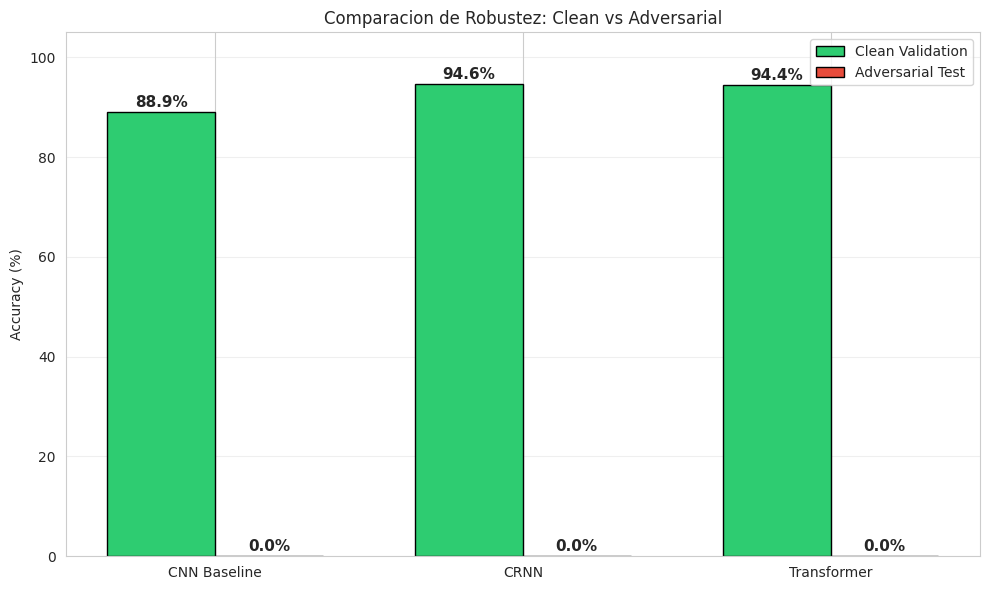

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))
model_names = ['CNN Baseline', 'CRNN', 'Transformer']
val_accs = [acc_cnn * 100, acc_crnn * 100, acc_trans * 100]
adv_accs_val = [adv_cnn * 100, adv_crnn * 100, adv_trans * 100]

x = np.arange(len(model_names))
width = 0.35

bars1 = ax.bar(x - width/2, val_accs, width, label='Clean Validation', color='#2ecc71', edgecolor='black')
bars2 = ax.bar(x + width/2, adv_accs_val, width, label='Adversarial Test', color='#e74c3c', edgecolor='black')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Accuracy (%)')
ax.set_title('Comparacion de Robustez: Clean vs Adversarial')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.legend()
ax.set_ylim(0, 105)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
if adv_loader is not None:
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    for ax, (name, _) in zip(axes, models_info):
        cm = adv_results[name]['confusion_matrix']
        if cm is not None:
            cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True).clip(min=1)
            im = ax.imshow(cm_norm, interpolation='nearest', cmap='Blues', vmin=0, vmax=1)
            ax.set_title(f'{name} - Adv Test')
            ax.set_xlabel('Predicho')
            ax.set_ylabel('Real')
            fig.colorbar(im, ax=ax, fraction=0.046)
    plt.suptitle('Matrices de Confusion Normalizadas - Test Adversarial', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("Matrices de confusion no disponibles (sin labels adversariales)")

Matrices de confusion no disponibles (sin labels adversariales)


## Conclusiones

### Resultados en validación limpia

| Modelo | Accuracy | Parámetros | Épocas entrenadas |
|--------|----------|------------|-------------------|
| CNN Baseline | 88.94% | 173,251 | 30 |
| CRNN (BiLSTM-128) | **94.64%** | 1,303,395 | 22 (early stop) |
| Spectrogram Transformer (dim=120, depth=4) | 94.38% | 724,595 | 20 (early stop) |

La **CRNN** obtuvo el mejor accuracy (94.64%), seguida muy de cerca por el Transformer (94.38%).
La CNN Baseline quedó ~5.7 puntos por detrás (88.94%), consistente con su menor capacidad.
Las clases más problemáticas para todos los modelos fueron aquellas con pocas muestras o
similitud acústica: `learn`, `forward`, `follow`, `tree`.

### Evaluación adversarial

No fue posible evaluar en el conjunto adversarial (`adv_test/`) porque el archivo
`test_metadata.csv` no contiene columna `label`. Esto impide calcular métricas de
clasificación. Para una evaluación completa, se requeriría que el dataset adversarial
incluyera etiquetas, o bien generar ataques ad-hoc (FGSM, PGD) sobre el conjunto de
validaci\u00f3n.

### Lecciones aprendidas

- La **CRNN con BiLSTM** ofrece el mejor balance entre capacidad y generalización para
  clasificación de comandos de voz en este dataset.
- El **Transformer con RoPE** es competitivo (solo 0.26% menos) y podría beneficiarse de
  una dimensión interna mayor (ej. dim=256) y más datos de entrenamiento.
- La **CNN Baseline** es un punto de referencia sólido pero significativamente inferior
  a las arquitecturas con modelado secuencial.
- Para una evaluación adversarial con sentido, el dataset de test necesita incluir
  etiquetas reales, o deben generarse ataques adversariales de forma controlada.